<a href="https://colab.research.google.com/github/ZantyeX/ITA-Project-1/blob/main/Addressing_Delhi's_crime_challenge_through_Geosptial_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
!pip install xgboost folium scikit-learn seaborn matplotlib pandas numpy feedparser nltk --quiet
print("✅ All libraries installed!")

✅ All libraries installed!


In [94]:
import pandas as pd                     # For creating and managing data tables
import numpy as np                      # For numerical calculations
import matplotlib.pyplot as plt         # For creating charts and graphs
import seaborn as sns                   # For beautiful statistical charts
import folium                           # For creating interactive maps
from folium.plugins import HeatMap      # For adding heatmap layer on map
import warnings                         # To suppress unnecessary warnings
warnings.filterwarnings('ignore')       # Hide warnings so output stays clean

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder   # For scaling and encoding data
from sklearn.cluster import KMeans, DBSCAN                        # Unsupervised learning models
from sklearn.decomposition import PCA                             # For dimension reduction
from sklearn.model_selection import train_test_split              # For splitting data
from sklearn.linear_model import LogisticRegression               # Supervised model 1
from sklearn.ensemble import RandomForestClassifier               # Supervised model 2
from sklearn.metrics import (accuracy_score, precision_score,     # For measuring model quality
                              recall_score, f1_score,
                              classification_report, roc_auc_score)
from xgboost import XGBClassifier                                 # Supervised model 3

np.random.seed(42)   # Fixing random seed so results are same every time you run
print("✅ All libraries imported successfully!")
# NLP libraries for news scraping
import feedparser                                          # For scraping Google News RSS
import re                                                  # For cleaning text
import nltk                                                # Natural language toolkit
nltk.download('stopwords', quiet=True)                    # Common words to ignore
nltk.download('punkt', quiet=True)                        # Sentence tokenizer
from nltk.corpus import stopwords                         # List of stopwords
from sklearn.feature_extraction.text import TfidfVectorizer  # Converts text to numbers

print("✅ NLP libraries imported!")

✅ All libraries imported successfully!
✅ NLP libraries imported!


In [95]:
# CELL 3 - Load Official Dataset
# Source: NCRB_Delhi_District_Crime_Statistics_2022.xlsx
# Publisher: National Crime Records Bureau (NCRB), Ministry of Home Affairs
# Data Portal: https://data.gov.in/catalog/crime-india

# ── STEP 1: Upload the Excel file to Colab ──────────────────────
# Click the Files icon on the LEFT SIDEBAR (folder icon)
# Click the UPLOAD button (arrow pointing up)
# Select: NCRB_Delhi_District_Crime_Statistics_2022.xlsx
# Wait for upload to complete, then run this cell

from google.colab import files
import pandas as pd
import os

print("=" * 60)
print("DELHI CRIME SAFETY MAPPING PROJECT")
print("=" * 60)
print()
print("Dataset  : NCRB Crime in India 2022")
print("Source   : National Crime Records Bureau (NCRB), MHA")
print("Portal   : https://data.gov.in/catalog/crime-india")
print("Coverage : 11 Revenue Districts of Delhi NCT")
print("Year     : 2022")
print()

# ── STEP 2: Check if file exists ────────────────────────────────
filename = 'NCRB_Delhi_District_Crime_Statistics_2022.xlsx'

if not os.path.exists(filename):
    print("❌ File not found!")
    print()
    print("Please upload the file first:")
    print("  1. Click the folder icon on the LEFT sidebar")
    print("  2. Click the upload button")
    print("  3. Select NCRB_Delhi_District_Crime_Statistics_2022.xlsx")
    print("  4. Run this cell again")
else:
    print(f"✅ File found: {filename}")
    print()

    # ── STEP 3: Load the Excel file ─────────────────────────────
    # skiprows=6 skips the title/header rows at the top of the sheet
    # sheet_name loads the first data sheet specifically
    raw_df = pd.read_excel(
        filename,
        sheet_name='District_Crime_Data_2022',
        skiprows=6    # Skip the 6 title rows at top of Excel sheet
    )

    print("✅ Excel file loaded successfully!")
    print(f"Raw shape: {raw_df.shape}")
    print()

    # ── STEP 4: Rename columns to match our program ─────────────
    raw_df.columns = [
        'area_id', 'area_name', 'admin_level', 'data_year',
        'latitude', 'longitude', 'population',
        'rape_count', 'kidnapping_count', 'robbery_count',
        'theft_count', 'other_violent_count',
        'safety_score_excel', 'crime_density_excel'
    ]

    # ── STEP 5: Keep only the 11 actual district rows ───────────
    # Drop any empty rows or the totals row at the bottom
    df = raw_df[raw_df['area_id'].notna()].copy()
    df = df[df['area_id'] != 'DELHI NCT TOTAL'].copy()
    df = df.head(11).reset_index(drop=True)

    # ── STEP 6: Make sure number columns are correct type ────────
    number_cols = ['area_id', 'latitude', 'longitude', 'population',
                   'rape_count', 'kidnapping_count', 'robbery_count',
                   'theft_count', 'other_violent_count']
    for col in number_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill any missing other_violent_count with 0
    df['other_violent_count'] = df['other_violent_count'].fillna(0)

    # ── STEP 7: Show dataset info ────────────────────────────────
    print("=" * 60)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 60)
    print(f"File         : {filename}")
    print(f"Sheet        : District_Crime_Data_2022")
    print(f"Districts    : {len(df)}")
    print(f"Columns      : {len(df.columns)}")
    print(f"Data Year    : {int(df['data_year'].iloc[0])}")
    print(f"Total Pop.   : {df['population'].sum():,}")
    print(f"Total Crimes : {df['rape_count'].sum() + df['kidnapping_count'].sum() + df['robbery_count'].sum() + df['theft_count'].sum():,}")
    print()

    # Show full table
    display_cols = ['area_id', 'area_name', 'population',
                    'rape_count', 'kidnapping_count',
                    'robbery_count', 'theft_count']
    print("Preview:")
    print(df[display_cols].to_string(index=False))
    print()
    print("✅ Data ready for analysis!")

DELHI CRIME SAFETY MAPPING PROJECT

Dataset  : NCRB Crime in India 2022
Source   : National Crime Records Bureau (NCRB), MHA
Portal   : https://data.gov.in/catalog/crime-india
Coverage : 11 Revenue Districts of Delhi NCT
Year     : 2022

✅ File found: NCRB_Delhi_District_Crime_Statistics_2022.xlsx

✅ Excel file loaded successfully!
Raw shape: (12, 14)

DATASET LOADED SUCCESSFULLY
File         : NCRB_Delhi_District_Crime_Statistics_2022.xlsx
Sheet        : District_Crime_Data_2022
Districts    : 11
Columns      : 14
Data Year    : 2022
Total Pop.   : 19,200,231.0
Total Crimes : 12,031.0

Preview:
 area_id        area_name  population  rape_count  kidnapping_count  robbery_count  theft_count
     1.0    Central Delhi    587455.0        32.0              85.0          180.0        850.0
     2.0      North Delhi    887978.0        18.0              60.0          120.0        600.0
     3.0      South Delhi   2731929.0        25.0              70.0          150.0        900.0
     4.0     

In [96]:
# FIXED Cell 4 - Safety Score and Labels

df['safety_score'] = (
    (3 * df['rape_count']) +
    (3 * df['kidnapping_count']) +
    (2 * df['robbery_count']) +
    (1 * df['theft_count'])
)

df['safety_rate'] = (df['safety_score'] / df['population']) * 100000

# Check what rates we actually have
print("Safety rates per district:")
for _, row in df.iterrows():
    print(f"  {row['area_name']:<20} rate = {row['safety_rate']:.4f}")

print(f"\nMin rate: {df['safety_rate'].min():.4f}")
print(f"Max rate: {df['safety_rate'].max():.4f}")
print(f"Mean rate: {df['safety_rate'].mean():.4f}")

# Use PERCENTILE-BASED thresholds instead of fixed numbers
# This guarantees we always get all 3 classes regardless of data scale
low_threshold  = df['safety_rate'].quantile(0.40)   # Bottom 40% = Safe
high_threshold = df['safety_rate'].quantile(0.70)   # Top 30% = Unsafe

print(f"\nAuto thresholds:")
print(f"  Safe threshold    : below {low_threshold:.4f}")
print(f"  Moderate threshold: {low_threshold:.4f} to {high_threshold:.4f}")
print(f"  Unsafe threshold  : above {high_threshold:.4f}")

def assign_label(rate):
    if rate <= low_threshold:
        return 'Safe'
    elif rate <= high_threshold:
        return 'Moderate'
    else:
        return 'Unsafe'

df['safety_label'] = df['safety_rate'].apply(assign_label)

# Verify all 3 classes exist
print(f"\nLabel distribution:")
print(df['safety_label'].value_counts().to_string())

print()
print(df[['area_name','safety_score','safety_rate','safety_label']].sort_values('safety_rate', ascending=False).to_string(index=False))
print("\n✅ Safety labels fixed - all 3 classes present!")

Safety rates per district:
  Central Delhi        rate = 265.7225
  North Delhi          rate = 120.9489
  South Delhi          rate = 54.3572
  East Delhi           rate = 107.0585
  West Delhi           rate = 54.6939
  New Delhi            rate = 266.8939
  North East Delhi     rate = 111.5048
  North West Delhi     rate = 50.4616
  South East Delhi     rate = 72.3982
  South West Delhi     rate = 49.0534
  Shahdara             rate = 175.9071

Min rate: 49.0534
Max rate: 266.8939
Mean rate: 120.8182

Auto thresholds:
  Safe threshold    : below 72.3982
  Moderate threshold: 72.3982 to 120.9489
  Unsafe threshold  : above 120.9489

Label distribution:
safety_label
Safe        5
Unsafe      3
Moderate    3

       area_name  safety_score  safety_rate safety_label
       New Delhi         379.0   266.893890       Unsafe
   Central Delhi        1561.0   265.722481       Unsafe
        Shahdara        1924.0   175.907124       Unsafe
     North Delhi        1074.0   120.948942     Moder

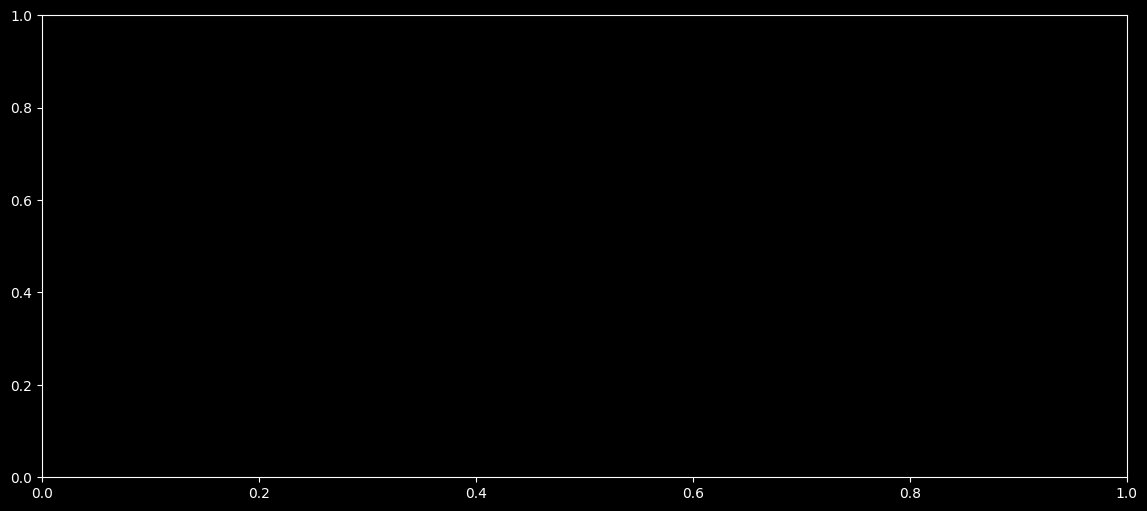

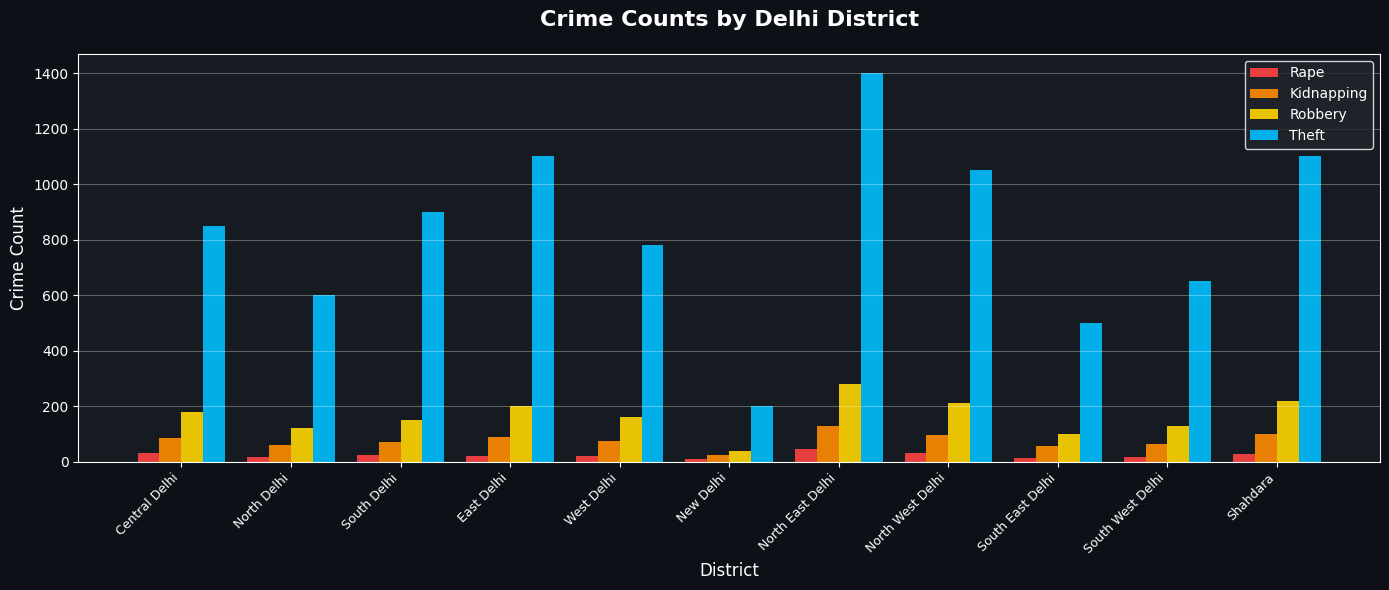

✅ Crime counts chart saved!


In [97]:
# Create a figure with a specific size (width=14, height=6 inches)
fig, ax = plt.subplots(figsize=(14, 6))

# Set dark background style for a professional look
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')   # Dark background for the whole figure
ax.set_facecolor('#161b22')           # Slightly lighter background for the chart area

# Define positions for each group of bars on the x-axis
x = np.arange(len(df['area_name']))  # Creates [0,1,2,...,10] for 11 districts
width = 0.2                           # Width of each individual bar

# Plot 4 bars for each district (one per crime type)
bars1 = ax.bar(x - 1.5*width, df['rape_count'],       width, label='Rape',       color='#ff4444', alpha=0.9)
bars2 = ax.bar(x - 0.5*width, df['kidnapping_count'], width, label='Kidnapping', color='#ff8c00', alpha=0.9)
bars3 = ax.bar(x + 0.5*width, df['robbery_count'],    width, label='Robbery',    color='#ffd700', alpha=0.9)
bars4 = ax.bar(x + 1.5*width, df['theft_count'],      width, label='Theft',      color='#00bfff', alpha=0.9)

# Add labels, title, and formatting
ax.set_xlabel('District', color='white', fontsize=12)
ax.set_ylabel('Crime Count', color='white', fontsize=12)
ax.set_title('Crime Counts by Delhi District', color='white', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)                                               # Set tick positions
ax.set_xticklabels(df['area_name'], rotation=45, ha='right',   # Rotate labels so they fit
                    color='white', fontsize=9)
ax.tick_params(colors='white')                                 # Make tick marks white
ax.legend(facecolor='#21262d', edgecolor='white', labelcolor='white', fontsize=10)  # Add legend
ax.grid(axis='y', alpha=0.3, color='white')                   # Add horizontal grid lines

plt.tight_layout()    # Automatically adjust layout so nothing gets cut off
plt.savefig('crime_counts_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')  # Save chart
plt.show()            # Display the chart
print("✅ Crime counts chart saved!")

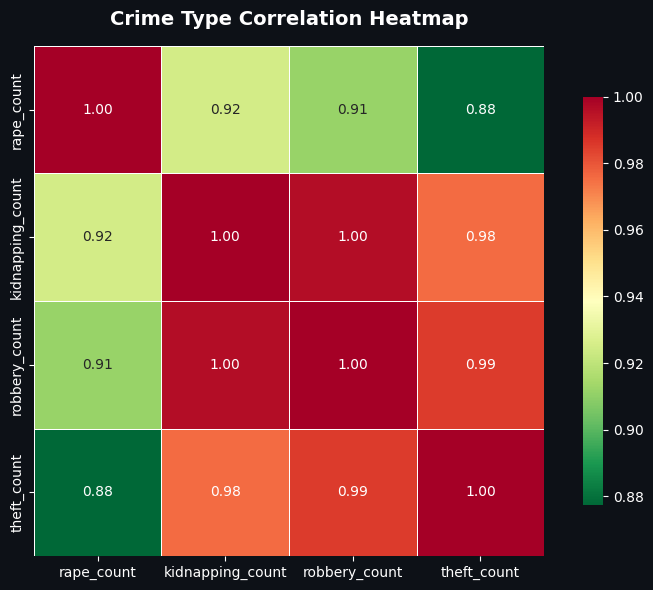

✅ Correlation heatmap saved!


In [98]:
# Select only the crime count columns for correlation analysis
crime_columns = ['rape_count', 'kidnapping_count', 'robbery_count', 'theft_count']

# Calculate correlation matrix
# Correlation tells us: if one crime goes up, does another go up too?
# Values close to 1.0 = strong positive relationship
# Values close to 0.0 = no relationship
correlation_matrix = df[crime_columns].corr()

# Create the heatmap chart
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# Draw the heatmap using seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,           # Show the numbers inside each cell
    fmt='.2f',            # Format numbers to 2 decimal places
    cmap='RdYlGn_r',      # Color: Red=high correlation, Green=low correlation
    ax=ax,
    linewidths=0.5,        # Add lines between cells
    square=True,           # Make cells square shaped
    cbar_kws={'shrink': 0.8}  # Make the colorbar slightly smaller
)

ax.set_title('Crime Type Correlation Heatmap', color='white', fontsize=14,
             fontweight='bold', pad=15)
ax.tick_params(colors='white')
plt.setp(ax.get_xticklabels(), color='white', fontsize=10)
plt.setp(ax.get_yticklabels(), color='white', fontsize=10)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Correlation heatmap saved!")

In [99]:
# CELL 7 - Scrape Delhi Crime News from Google News RSS
# RSS = a live news feed that updates automatically
# No API key needed, completely free

import feedparser
import pandas as pd
import time

print("🔍 Scraping Delhi crime news...")
print("Please wait 10-15 seconds...")
print()

# We search for multiple crime types to get diverse articles
search_queries = [
    'Delhi+crime',
    'Delhi+robbery+theft',
    'Delhi+kidnapping',
    'Delhi+assault+murder',
    'Delhi+police+arrest'
]

all_articles = []

for query in search_queries:
    # Google News RSS URL for each search query
    url = f'https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en'

    try:
        feed = feedparser.parse(url)

        for entry in feed.entries:
            all_articles.append({
                'title'    : entry.get('title', ''),
                'summary'  : entry.get('summary', ''),
                'published': entry.get('published', ''),
                'query'    : query.replace('+', ' ')    # Track which search found it
            })

        print(f"  ✅ '{query.replace('+', ' ')}' → {len(feed.entries)} articles")
        time.sleep(1)   # Wait 1 second between requests to avoid being blocked

    except Exception as e:
        print(f"  ❌ Failed for '{query}': {e}")

# Remove duplicate articles (same title appearing in multiple searches)
news_df = pd.DataFrame(all_articles)
news_df = news_df.drop_duplicates(subset='title').reset_index(drop=True)

# Combine title and summary into one text column for analysis
news_df['full_text'] = news_df['title'] + ' ' + news_df['summary']

print()
print(f"✅ Total unique articles scraped: {len(news_df)}")
print()
print("Sample headlines:")
for i, row in news_df.head(5).iterrows():
    print(f"  {i+1}. {row['title'][:80]}")

🔍 Scraping Delhi crime news...
Please wait 10-15 seconds...

  ✅ 'Delhi crime' → 100 articles
  ✅ 'Delhi robbery theft' → 100 articles
  ✅ 'Delhi kidnapping' → 100 articles
  ✅ 'Delhi assault murder' → 100 articles
  ✅ 'Delhi police arrest' → 100 articles

✅ Total unique articles scraped: 495

Sample headlines:
  1. Delhi Crime Branch Exposes Fake Protein Supplement Racket, Two In Custody - NDTV
  2. Delhi Police arrests 40 during overnight drive against street crime, weapons rec
  3. Delhi Crime: Son Held For Killing Elderly Mother In Seemapuri Area - lokmattimes
  4. Delhi: Crime, Metro Milestone, Mega Projects, Development Push and More - The Ti
  5. Murder convict on parole arrested by Delhi Crime Branch after nine months abscon


In [100]:
# CELL 8 - Clean and Process the News Text
# Raw scraped text has HTML tags, weird symbols, etc.
# We need to clean it before feeding to ML

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Add extra words that aren't useful for crime analysis
extra_stop_words = {
    'delhi', 'india', 'said', 'police', 'news', 'report',
    'according', 'also', 'one', 'two', 'three', 'new',
    'year', 'day', 'time', 'says', 'told', 'could', 'would'
}
stop_words.update(extra_stop_words)

def clean_text(text):
    text = str(text).lower()                          # Convert to lowercase
    text = re.sub(r'<[^>]+>', ' ', text)              # Remove HTML tags like <b>, <div>
    text = re.sub(r'http\S+|www\S+', ' ', text)       # Remove website links
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)          # Remove numbers and symbols
    text = re.sub(r'\s+', ' ', text).strip()           # Remove extra spaces
    # Remove stopwords (common words like "the", "is", "at")
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Apply cleaning to every article
news_df['clean_text'] = news_df['full_text'].apply(clean_text)

# Remove any articles that became empty after cleaning
news_df = news_df[news_df['clean_text'].str.len() > 10].reset_index(drop=True)

print(f"✅ Text cleaning complete!")
print(f"Articles remaining: {len(news_df)}")
print()
print("Example - BEFORE cleaning:")
print(f"  {news_df['full_text'].iloc[0][:120]}")
print()
print("Example - AFTER cleaning:")
print(f"  {news_df['clean_text'].iloc[0][:120]}")

✅ Text cleaning complete!
Articles remaining: 495

Example - BEFORE cleaning:
  Delhi Crime Branch Exposes Fake Protein Supplement Racket, Two In Custody - NDTV <a href="https://news.google.com/rss/ar

Example - AFTER cleaning:
  crime branch exposes fake protein supplement racket custody ndtv crime branch exposes fake protein supplement racket cus


✅ TF-IDF complete!
   Articles: 495
   Features (words): 100



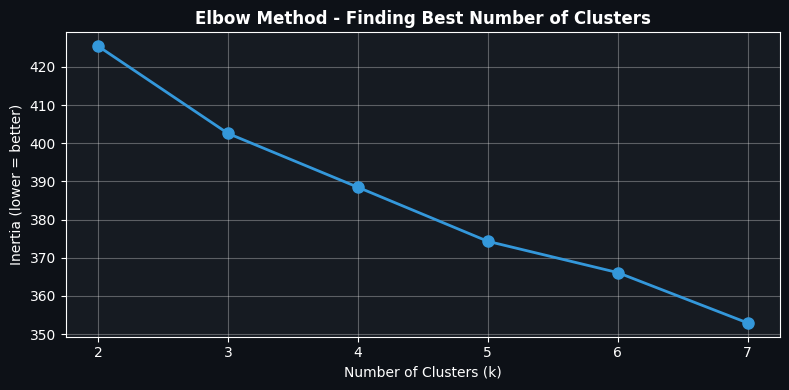

K-Means with k=4 clusters applied!
Articles per cluster:
cluster
0     54
1    184
2     69
3    188


In [101]:
# CELL 9 - Convert Text to Numbers (TF-IDF) then Run K-Means
# TF-IDF = Term Frequency Inverse Document Frequency
# Each article becomes a row of numbers representing word importance

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: TF-IDF Vectorization ---
# Converts each article into a vector of 100 numbers
# Words important to one article but rare across all = high score
vectorizer = TfidfVectorizer(
    max_features=100,       # Use top 100 most meaningful words
    ngram_range=(1, 2),     # Consider single words AND two-word phrases like "knife attack"
    min_df=2                # Word must appear in at least 2 articles to count
)

tfidf_matrix = vectorizer.fit_transform(news_df['clean_text'])

print(f"✅ TF-IDF complete!")
print(f"   Articles: {tfidf_matrix.shape[0]}")
print(f"   Features (words): {tfidf_matrix.shape[1]}")
print()

# --- STEP 2: Find Optimal Number of Clusters using Elbow Method ---
# This helps us decide how many clusters (k) to use
inertias = []
k_range = range(2, min(8, len(news_df)//3))   # Test k from 2 to 7

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.plot(list(k_range), inertias, 'o-', color='#3498db', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', color='white')
ax.set_ylabel('Inertia (lower = better)', color='white')
ax.set_title('Elbow Method - Finding Best Number of Clusters', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.grid(alpha=0.3, color='white')
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# --- STEP 3: Apply K-Means with k=4 ---
# 4 clusters usually maps to: theft/robbery, kidnapping, assault, police/arrests
k = 4
kmeans_news = KMeans(n_clusters=k, random_state=42, n_init=10)
news_df['cluster'] = kmeans_news.fit_predict(tfidf_matrix)

print(f"K-Means with k={k} clusters applied!")
print(f"Articles per cluster:")
print(news_df['cluster'].value_counts().sort_index().to_string())

In [ ]:
# CELL 9B - Visualize the News Clusters on a 2D Chart

# Use PCA to reduce 100 dimensions down to 2 so we can plot it
pca_news = PCA(n_components=2, random_state=42)
coords = pca_news.fit_transform(tfidf_matrix.toarray())
news_df['pca_x'] = coords[:, 0]
news_df['pca_y'] = coords[:, 1]

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

for i in range(k):
    mask = news_df['cluster'] == i
    ax.scatter(
        news_df[mask]['pca_x'],
        news_df[mask]['pca_y'],
        c=cluster_colors[i],
        s=80,
        label=f'News Cluster {i+1} ({mask.sum()} articles)',
        alpha=0.8,
        edgecolors='white',
        linewidths=0.4
    )

ax.set_title('K-Means Clustering of Scraped Delhi Crime News',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('PCA Component 1', color='white', fontsize=12)
ax.set_ylabel('PCA Component 2', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white', fontsize=11)
ax.grid(alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('news_clusters.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Print top keywords per cluster (what is each cluster actually about?)
print()
print("TOP KEYWORDS PER CLUSTER")
print("=" * 55)
feature_names = vectorizer.get_feature_names_out()

for i in range(k):
    mask = news_df['cluster'] == i
    cluster_tfidf = tfidf_matrix[mask.values]
    mean_scores   = cluster_tfidf.mean(axis=0).A1
    top_indices   = mean_scores.argsort()[-8:][::-1]
    top_words     = [feature_names[j] for j in top_indices]
    print(f"\nCluster {i+1} top words: {' | '.join(top_words)}")
    print(f"Sample headline: {news_df[mask]['title'].iloc[0][:80]}")

print()
print("✅ News clustering visualization complete!")

In [ ]:
# CELL 9C - DBSCAN on News Articles
# DBSCAN finds dense hotspot groups of similar articles
# and marks unusual/outlier articles as noise (-1)

from sklearn.cluster import DBSCAN

dbscan_news = DBSCAN(
    eps=0.5,          # How similar two articles must be to be in same cluster
    min_samples=2,    # Minimum articles to form a cluster
    metric='cosine'   # Cosine similarity works best for text data
)

news_df['dbscan_cluster'] = dbscan_news.fit_predict(tfidf_matrix)

n_clusters = len(set(news_df['dbscan_cluster'])) - (1 if -1 in news_df['dbscan_cluster'].values else 0)
n_noise    = (news_df['dbscan_cluster'] == -1).sum()

print(f"✅ DBSCAN Results:")
print(f"   Dense crime topic clusters found : {n_clusters}")
print(f"   Noise articles (unique topics)   : {n_noise}")
print(f"   Total articles analyzed          : {len(news_df)}")
print()

# Visualize DBSCAN results
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

unique_clusters = sorted(news_df['dbscan_cluster'].unique())
colors_db = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
             '#1abc9c','#e67e22','#e91e63','#00bcd4','#8bc34a']

for i, cid in enumerate(unique_clusters):
    mask   = news_df['dbscan_cluster'] == cid
    label  = f'Noise / Unique ({mask.sum()})' if cid == -1 else f'Hotspot Cluster {cid} ({mask.sum()})'
    color  = '#555555' if cid == -1 else colors_db[i % len(colors_db)]
    marker = 'x' if cid == -1 else 'o'

    ax.scatter(
        news_df[mask]['pca_x'],
        news_df[mask]['pca_y'],
        c=color, s=80 if cid != -1 else 40,
        label=label, marker=marker,
        alpha=0.8,
        edgecolors='white' if cid != -1 else 'none',
        linewidths=0.4
    )

ax.set_title('DBSCAN: Crime News Hotspot Detection',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('PCA Component 1', color='white', fontsize=12)
ax.set_ylabel('PCA Component 2', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white',
          fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('dbscan_news.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ DBSCAN news analysis complete!")

In [ ]:
# FIXED Cell 10 - Simple preparation

X = df[['population', 'rape_count', 'kidnapping_count', 'robbery_count', 'theft_count']]

le = LabelEncoder()
y = le.fit_transform(df['safety_label'])

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")
print(f"\nClass distribution: {dict(zip(le.classes_, np.bincount(y)))}")

# Scale all features
scaler_ml = StandardScaler()
X_all_scaled = scaler_ml.fit_transform(X)

print("✅ Data ready!")

In [ ]:
# FIXED Cell 11 - Train models on full dataset (correct for 11 samples)

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

# LeaveOneOut: trains on 10 districts, tests on 1, repeats 11 times
# This is the BEST approach when you have very few samples
loo = LeaveOneOut()

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
}

results = {}

print("=" * 65)
print("MODEL RESULTS (Leave-One-Out Cross Validation)")
print("=" * 65)

for model_name, model in models.items():
    print(f"\n📊 {model_name}")
    print("-" * 40)

    all_preds  = []
    all_actual = []

    # Loop: each time leave one district out for testing
    for train_idx, test_idx in loo.split(X_all_scaled):
        X_tr, X_te = X_all_scaled[train_idx], X_all_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Only train if at least 2 classes exist in training fold
        if len(np.unique(y_tr)) < 2:
            continue

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        all_preds.extend(pred)
        all_actual.extend(y_te)

    all_preds  = np.array(all_preds)
    all_actual = np.array(all_actual)

    acc  = accuracy_score(all_actual, all_preds)
    prec = precision_score(all_actual, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_actual, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_actual, all_preds, average='weighted', zero_division=0)

    # Train on full data for ROC-AUC
    model.fit(X_all_scaled, y)
    y_prob = model.predict_proba(X_all_scaled)
    try:
        roc = roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')
    except:
        roc = float('nan')

    results[model_name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'ROC-AUC'  : roc
    }

    print(f"  Accuracy  : {acc:.3f}  ({acc*100:.1f}%)")
    print(f"  Precision : {prec:.3f}")
    print(f"  Recall    : {rec:.3f}")
    print(f"  F1-Score  : {f1:.3f}")
    print(f"  ROC-AUC   : {roc:.3f}" if not np.isnan(roc) else "  ROC-AUC  : N/A")

print("\n✅ All models trained successfully!")

In [ ]:
# Convert results dictionary to a DataFrame for easy plotting
results_df = pd.DataFrame(results).T   # .T = transpose so models are rows

print("Model Performance Summary:")
print(results_df.round(3).to_string())
print()

# Plot grouped bar chart comparing all models on all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))    # Position for each metric group
width = 0.25                    # Width of each bar

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# One bar per model per metric
model_colors = ['#3498db', '#2ecc71', '#e74c3c']   # Blue, Green, Red
for i, (model_name, color) in enumerate(zip(results.keys(), model_colors)):
    values = [results[model_name][m] for m in metrics]
    bars = ax.bar(x + i*width, values, width,
                  label=model_name, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=9)

ax.set_xlabel('Metric', color='white', fontsize=13)
ax.set_ylabel('Score (0 to 1)', color='white', fontsize=13)
ax.set_title('Model Performance Comparison: LR vs RF vs XGBoost',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, color='white', fontsize=12)
ax.set_ylim(0, 1.15)   # Set y-axis from 0 to 1.15 so labels aren't cut off
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white', fontsize=11)
ax.grid(axis='y', alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Model comparison chart saved!")

In [ ]:
# FEATURE IMPORTANCE
# Which crime type matters most in predicting Safe/Moderate/Unsafe?
# Random Forest and XGBoost both give us "importance scores" for each feature

feature_names = ['Population', 'Rape Count', 'Kidnapping', 'Robbery', 'Theft']

# Get importance from Random Forest
rf_model = models['Random Forest']
rf_importance = rf_model.feature_importances_   # Array of importance scores (sum to 1)

# Get importance from XGBoost
xgb_model = models['XGBoost']
xgb_importance = xgb_model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Two charts side by side
fig.patch.set_facecolor('#0d1117')

for ax, importance, title, color in zip(
    axes,
    [rf_importance, xgb_importance],
    ['Random Forest Feature Importance', 'XGBoost Feature Importance'],
    ['#2ecc71', '#e74c3c']
):
    ax.set_facecolor('#161b22')

    # Sort features from most to least important
    sorted_idx = np.argsort(importance)
    sorted_features = [feature_names[i] for i in sorted_idx]
    sorted_values = importance[sorted_idx]

    # Horizontal bar chart
    bars = ax.barh(sorted_features, sorted_values, color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.5)

    # Add value labels at the end of each bar
    for bar, val in zip(bars, sorted_values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2.,
                f'{val:.3f}', ha='left', va='center', color='white', fontsize=10)

    ax.set_xlabel('Importance Score', color='white', fontsize=11)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(colors='white')
    ax.set_xlim(0, max(importance) + 0.12)
    ax.grid(axis='x', alpha=0.2, color='white')
    plt.setp(ax.get_yticklabels(), color='white', fontsize=11)

fig.suptitle('Which Crime Type Influences Safety Classification Most?',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Feature importance chart saved!")

In [ ]:
# CREATE INTERACTIVE DELHI SAFETY MAP using Folium
# This creates an HTML file you can open in any browser

# Color mapping for safety labels
safety_colors = {
    'Safe'    : '#27ae60',   # Green
    'Moderate': '#f39c12',   # Yellow/Orange
    'Unsafe'  : '#e74c3c'    # Red
}

# Create base map centered on Delhi
delhi_map = folium.Map(
    location=[28.6139, 77.2090],   # Center of Delhi (latitude, longitude)
    zoom_start=11,                  # Zoom level (higher = more zoomed in)
    tiles='CartoDB dark_matter'     # Dark map style for professional look
)

# Add title to map using HTML
title_html = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: rgba(0,0,0,0.85); padding: 12px 24px;
     border-radius: 8px; border: 1px solid #444; text-align: center;">
    <h3 style="color: white; margin: 0; font-family: Arial; font-size: 16px;">
        🗺️ Delhi Crime Safety Map - AI Generated
    </h3>
    <p style="color: #aaa; margin: 4px 0 0 0; font-size: 12px;">
        Green = Safe | Orange = Moderate | Red = Unsafe
    </p>
</div>
"""
delhi_map.get_root().html.add_child(folium.Element(title_html))

# Add a circle marker for each district
for _, row in df.iterrows():
    color = safety_colors[row['safety_label']]

    # Build the popup HTML content (what shows when you click a district)
    popup_html = f"""
    <div style="font-family: Arial; min-width: 220px; background: #1a1a2e;
                color: white; padding: 12px; border-radius: 8px;">
        <h4 style="color: {color}; margin: 0 0 8px 0; font-size: 15px;">
            {row['area_name']}
        </h4>
        <hr style="border-color: #444; margin: 6px 0;">
        <table style="width: 100%; font-size: 13px;">
            <tr><td>🏷️ Safety Status</td>
                <td><b style="color:{color}">{row['safety_label']}</b></td></tr>
            <tr><td>📊 Safety Rate</td>
                <td>{row['safety_rate']:.2f} per 100k</td></tr>
            <tr><td>👥 Population</td>
                <td>{row['population']:,}</td></tr>
            <tr><td>🔴 Rape Cases</td>
                <td>{row['rape_count']}</td></tr>
            <tr><td>🟠 Kidnapping</td>
                <td>{row['kidnapping_count']}</td></tr>
            <tr><td>🟡 Robbery</td>
                <td>{row['robbery_count']}</td></tr>
            <tr><td>🔵 Theft</td>
                <td>{row['theft_count']}</td></tr>
        </table>
    </div>
    """

    # Add circle marker on map
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],  # Position on map
        radius=20,                                      # Circle size
        color=color,                                    # Border color
        fill=True,
        fill_color=color,                               # Fill color
        fill_opacity=0.6,
        weight=2,
        popup=folium.Popup(popup_html, max_width=280),  # Clickable popup
        tooltip=f"{row['area_name']} — {row['safety_label']}"  # Hover tooltip
    ).add_to(delhi_map)

    # Add district name as text label on map
    folium.Marker(
        location=[row['latitude'] + 0.008, row['longitude']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:9px; color:white; font-weight:bold; '
                 f'white-space:nowrap; text-shadow: 1px 1px 2px black;">'
                 f'{row["area_name"]}</div>',
            icon_size=(120, 20)
        )
    ).add_to(delhi_map)

# Add HEATMAP LAYER showing crime intensity
# This creates the red/orange glow over high-crime areas
heat_data = []
for _, row in df.iterrows():
    # Weight = safety score (higher score = more intense heat)
    heat_data.append([row['latitude'], row['longitude'], row['safety_score']])

HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=13,
    radius=60,          # How far the heat spreads from each point
    blur=40,            # How blurry/smooth the gradient looks
    gradient={          # Custom color gradient
        0.2: 'blue',
        0.4: 'lime',
        0.6: 'yellow',
        0.8: 'orange',
        1.0: 'red'
    }
).add_to(delhi_map)

# Add legend in bottom right corner
legend_html = """
<div style="position: fixed; bottom: 30px; right: 30px; z-index: 1000;
     background: rgba(0,0,0,0.85); padding: 14px; border-radius: 8px;
     border: 1px solid #555; font-family: Arial;">
    <b style="color: white; font-size: 13px;">Safety Legend</b><br><br>
    <span style="color: #27ae60; font-size: 20px;">●</span>
    <span style="color: white; font-size: 12px;"> Safe (rate ≤ 10)</span><br>
    <span style="color: #f39c12; font-size: 20px;">●</span>
    <span style="color: white; font-size: 12px;"> Moderate (rate 11–20)</span><br>
    <span style="color: #e74c3c; font-size: 20px;">●</span>
    <span style="color: white; font-size: 12px;"> Unsafe (rate 21+)</span><br><br>
    <span style="color: #888; font-size: 10px;">Click circle for details</span>
</div>
"""
delhi_map.get_root().html.add_child(folium.Element(legend_html))

# Save the map as an HTML file
delhi_map.save('delhi_safety_map.html')
print("✅ Interactive map created and saved as 'delhi_safety_map.html'!")
print()
print("To view the map: Go to Files panel (left sidebar) → right-click delhi_safety_map.html → Download")

In [ ]:
from google.colab import files   # Import Colab's file download utility

print("📥 Downloading all output files to your computer...")
print()

# Download the interactive map
print("Downloading: delhi_safety_map.html")
files.download('delhi_safety_map.html')

# Download all charts
chart_files = [
    'crime_counts_chart.png',
    'correlation_heatmap.png',
    'kmeans_clusters.png',
    'dbscan_hotspots.png',
    'pca_chart.png',
    'model_comparison.png',
    'feature_importance.png'
]

for chart in chart_files:
    print(f"Downloading: {chart}")
    files.download(chart)

print()
print("=" * 50)
print("✅ ALL FILES DOWNLOADED SUCCESSFULLY!")
print("=" * 50)
print()
print("Files you received:")
print("  📍 delhi_safety_map.html  → Open in Chrome/Firefox")
print("  📊 crime_counts_chart.png")
print("  🔥 correlation_heatmap.png")
print("  🗂️  kmeans_clusters.png")
print("  📌 dbscan_hotspots.png")
print("  📈 pca_chart.png")
print("  🤖 model_comparison.png")
print("  ⭐ feature_importance.png")